# 05 — Figuri și Tabele pentru Lucrare

Generează toate figurile și tabelele necesare pentru teză:

| ID | Conținut |
|----|----------|
| T1 | Comparație detectoare A22 vs A3-final |
| T2 | Comparație clasificatoare B2 vs B3 (per-clasă) |
| T3 | Comparație pipeline end-to-end C1 vs C2 |
| F1 | Curbe de antrenare detector A3-final |
| F2 | Curbe de antrenare clasificator B2 |
| F3 | Matrice de confuzie B2 (copie din runs/) |
| F4 | Scoruri F1 per-clasă: B2 vs B3 |
| F5 | Distribuție clase dataset TrashNet (B2) |
| F6 | Distribuție materiale detectate — C2 pipeline |

Toate figurile sunt salvate în `outputs/thesis_figures/` la 150 DPI.

---
## Setup

In [1]:

import json
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT  = Path('../..').resolve()
OUT_DIR    = REPO_ROOT / 'outputs/thesis_figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':       150,
    'savefig.dpi':      150,
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.labelsize':   11,
    'legend.fontsize':  10,
    'figure.facecolor': 'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
})

COLORS = plt.cm.Set2.colors
print('Output dir:', OUT_DIR)
print('Ready.')


Output dir: D:\TrashDetectionSystem\outputs\thesis_figures
Ready.


---
## T1 — Comparație Detectoare: A22 vs A3-final

In [2]:
# ── Load detector results ─────────────────────────────────────────────────────
with open(REPO_ROOT / 'results/detector/A22-test.json') as f:
    a22 = json.load(f)
with open(REPO_ROOT / 'results/detector/A3-final-test.json') as f:
    a3  = json.load(f)

t1_rows = [
    {
        'Model':        'A22 — YOLOv8n',
        'imgsz':        416,
        'Params (M)':   3.2,
        'Precision':    round(a22['precision'], 3),
        'Recall':       round(a22['recall'], 3),
        'mAP50':        round(a22['map50'], 3),
        'mAP50-95':     round(a22['map50_95'], 3),
    },
    {
        'Model':        'A3-final — YOLOv8s',
        'imgsz':        640,
        'Params (M)':   11.2,
        'Precision':    round(a3['precision'], 3),
        'Recall':       round(a3['recall'], 3),
        'mAP50':        round(a3['mAP50'], 3),
        'mAP50-95':     round(a3['mAP50_95'], 3),
    },
]
df_t1 = pd.DataFrame(t1_rows).set_index('Model')
print('=== T1 — Comparație Detectoare (test set) ===')
print(df_t1.to_string())
df_t1

=== T1 — Comparație Detectoare (test set) ===
                    imgsz  Params (M)  Precision  Recall  mAP50  mAP50-95
Model                                                                    
A22 — YOLOv8n         416         3.2      0.707   0.286  0.393     0.281
A3-final — YOLOv8s    640        11.2      0.623   0.406  0.443     0.321


,imgsz,Params (M),Precision,Recall,mAP50,mAP50-95
Model,,,,,,
A22 — YOLOv8n,416,3.2,0.707,0.286,0.393,0.281
A3-final — YOLOv8s,640,11.2,0.623,0.406,0.443,0.321


---
## T2 — Comparație Clasificatoare: B2 vs B3

In [3]:
# ── Load classifier results ───────────────────────────────────────────────────
with open(REPO_ROOT / 'runs/classify_eval/eval-B2-test/test/summary.json') as f:
    b2 = json.load(f)
with open(REPO_ROOT / 'runs/classify_eval/eval-B3-test/test/summary.json') as f:
    b3 = json.load(f)

CLASSES = ['glass', 'metal', 'other', 'paper', 'plastic']

# ── Global metrics table ──────────────────────────────────────────────────────
t2_global = pd.DataFrame([
    {
        'Model':           'B2 — YOLOv8n-cls (TrashNet)',
        'Test images':     b2['num_images'],
        'Accuracy':        round(b2['accuracy'], 3),
        'Macro Precision': round(b2['macro_precision'], 3),
        'Macro Recall':    round(b2['macro_recall'], 3),
        'Macro F1':        round(b2['macro_f1'], 3),
    },
    {
        'Model':           'B3 — YOLOv8n-cls (Mixed)',
        'Test images':     b3['num_images'],
        'Accuracy':        round(b3['accuracy'], 3),
        'Macro Precision': round(b3['macro_precision'], 3),
        'Macro Recall':    round(b3['macro_recall'], 3),
        'Macro F1':        round(b3['macro_f1'], 3),
    },
]).set_index('Model')

print('=== T2 — Metrici globale clasificatoare ===')
print(df_t2_global := t2_global)

# ── Per-class F1 table ────────────────────────────────────────────────────────
rows_pc = []
for cls in CLASSES:
    rows_pc.append({
        'Clasă':    cls,
        'B2 P':     round(b2['per_class'][cls]['precision'], 3),
        'B2 R':     round(b2['per_class'][cls]['recall'], 3),
        'B2 F1':    round(b2['per_class'][cls]['f1'], 3),
        'B2 supp':  b2['per_class'][cls]['support'],
        'B3 P':     round(b3['per_class'][cls]['precision'], 3),
        'B3 R':     round(b3['per_class'][cls]['recall'], 3),
        'B3 F1':    round(b3['per_class'][cls]['f1'], 3),
        'B3 supp':  b3['per_class'][cls]['support'],
    })
df_t2_pc = pd.DataFrame(rows_pc).set_index('Clasă')
print('\n=== T2 — Metrici per-clasă ===')
print(df_t2_pc.to_string())
df_t2_pc

=== T2 — Metrici globale clasificatoare ===
                             Test images  Accuracy  Macro Precision  \
Model                                                                 
B2 — YOLOv8n-cls (TrashNet)          257     0.911            0.867   
B3 — YOLOv8n-cls (Mixed)             299     0.913            0.871   

                             Macro Recall  Macro F1  
Model                                                
B2 — YOLOv8n-cls (TrashNet)         0.914     0.881  
B3 — YOLOv8n-cls (Mixed)            0.892     0.879  

=== T2 — Metrici per-clasă ===
          B2 P   B2 R  B2 F1  B2 supp   B3 P   B3 R  B3 F1  B3 supp
Clasă                                                              
glass    0.977  0.824  0.894       51  0.925  0.925  0.925       53
metal    0.830  0.951  0.886       41  0.926  0.847  0.885       59
other    0.609  0.933  0.737       15  0.650  0.812  0.722       16
paper    0.979  0.921  0.949      101  0.949  0.949  0.949      118
plastic  0.939 

,B2 P,B2 R,B2 F1,B2 supp,B3 P,B3 R,B3 F1,B3 supp
Clasă,,,,,,,,
glass,0.977,0.824,0.894,51,0.925,0.925,0.925,53
metal,0.830,0.951,0.886,41,0.926,0.847,0.885,59
other,0.609,0.933,0.737,15,0.650,0.812,0.722,16
paper,0.979,0.921,0.949,101,0.949,0.949,0.949,118
plastic,0.939,0.939,0.939,49,0.907,0.925,0.916,53


---
## T3 — Comparație Pipeline: C1 vs C2

In [4]:
# ── Load pipeline results ─────────────────────────────────────────────────────
with open(REPO_ROOT / 'results/pipeline/C1-summary.json') as f:
    c1 = json.load(f)
with open(REPO_ROOT / 'results/pipeline/C2-summary.json') as f:
    c2 = json.load(f)

df_t3 = pd.DataFrame([
    {
        'Pipeline':         c1['label'],
        'Detector':         'YOLOv8n (A22)',
        'det_imgsz':        c1['det_imgsz'],
        'Imagini test':     c1['test_images'],
        'Cu detecții':      c1['imgs_with_det'],
        'Rată detecție %':  f"{c1['detection_rate']*100:.1f}%",
        'Total detecții':   c1['total_detections'],
        'Avg det/img':      c1['avg_det_per_img'],
        'Avg ms/img':       c1['avg_ms_per_img'],
    },
    {
        'Pipeline':         c2['label'],
        'Detector':         'YOLOv8s (A3-final)',
        'det_imgsz':        c2['det_imgsz'],
        'Imagini test':     c2['test_images'],
        'Cu detecții':      c2['imgs_with_det'],
        'Rată detecție %':  f"{c2['detection_rate']*100:.1f}%",
        'Total detecții':   c2['total_detections'],
        'Avg det/img':      c2['avg_det_per_img'],
        'Avg ms/img':       c2['avg_ms_per_img'],
    },
]).set_index('Pipeline')

print('=== T3 — Comparație Pipeline End-to-End ===')
print(df_t3.to_string())
df_t3

=== T3 — Comparație Pipeline End-to-End ===
                                        Detector  det_imgsz  Imagini test  Cu detecții Rată detecție %  Total detecții  Avg det/img  Avg ms/img
Pipeline                                                                                                                                       
C1 — A22 (yolov8n) + B2            YOLOv8n (A22)        416           227            9            4.0%              10         0.04        26.3
C2 — A3-final (yolov8s) + B2  YOLOv8s (A3-final)        640           227          219           96.5%             739         3.26        74.7


,Detector,det_imgsz,Imagini test,Cu detecții,Rată detecție %,Total detecții,Avg det/img,Avg ms/img
Pipeline,,,,,,,,
C1 — A22 (yolov8n) + B2,YOLOv8n (A22),416,227,9,4.0%,10,0.04,26.3
C2 — A3-final (yolov8s) + B2,YOLOv8s (A3-final),640,227,219,96.5%,739,3.26,74.7


---
## F1 — Curbe de Antrenare: Detector A3-final (YOLOv8s)

Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


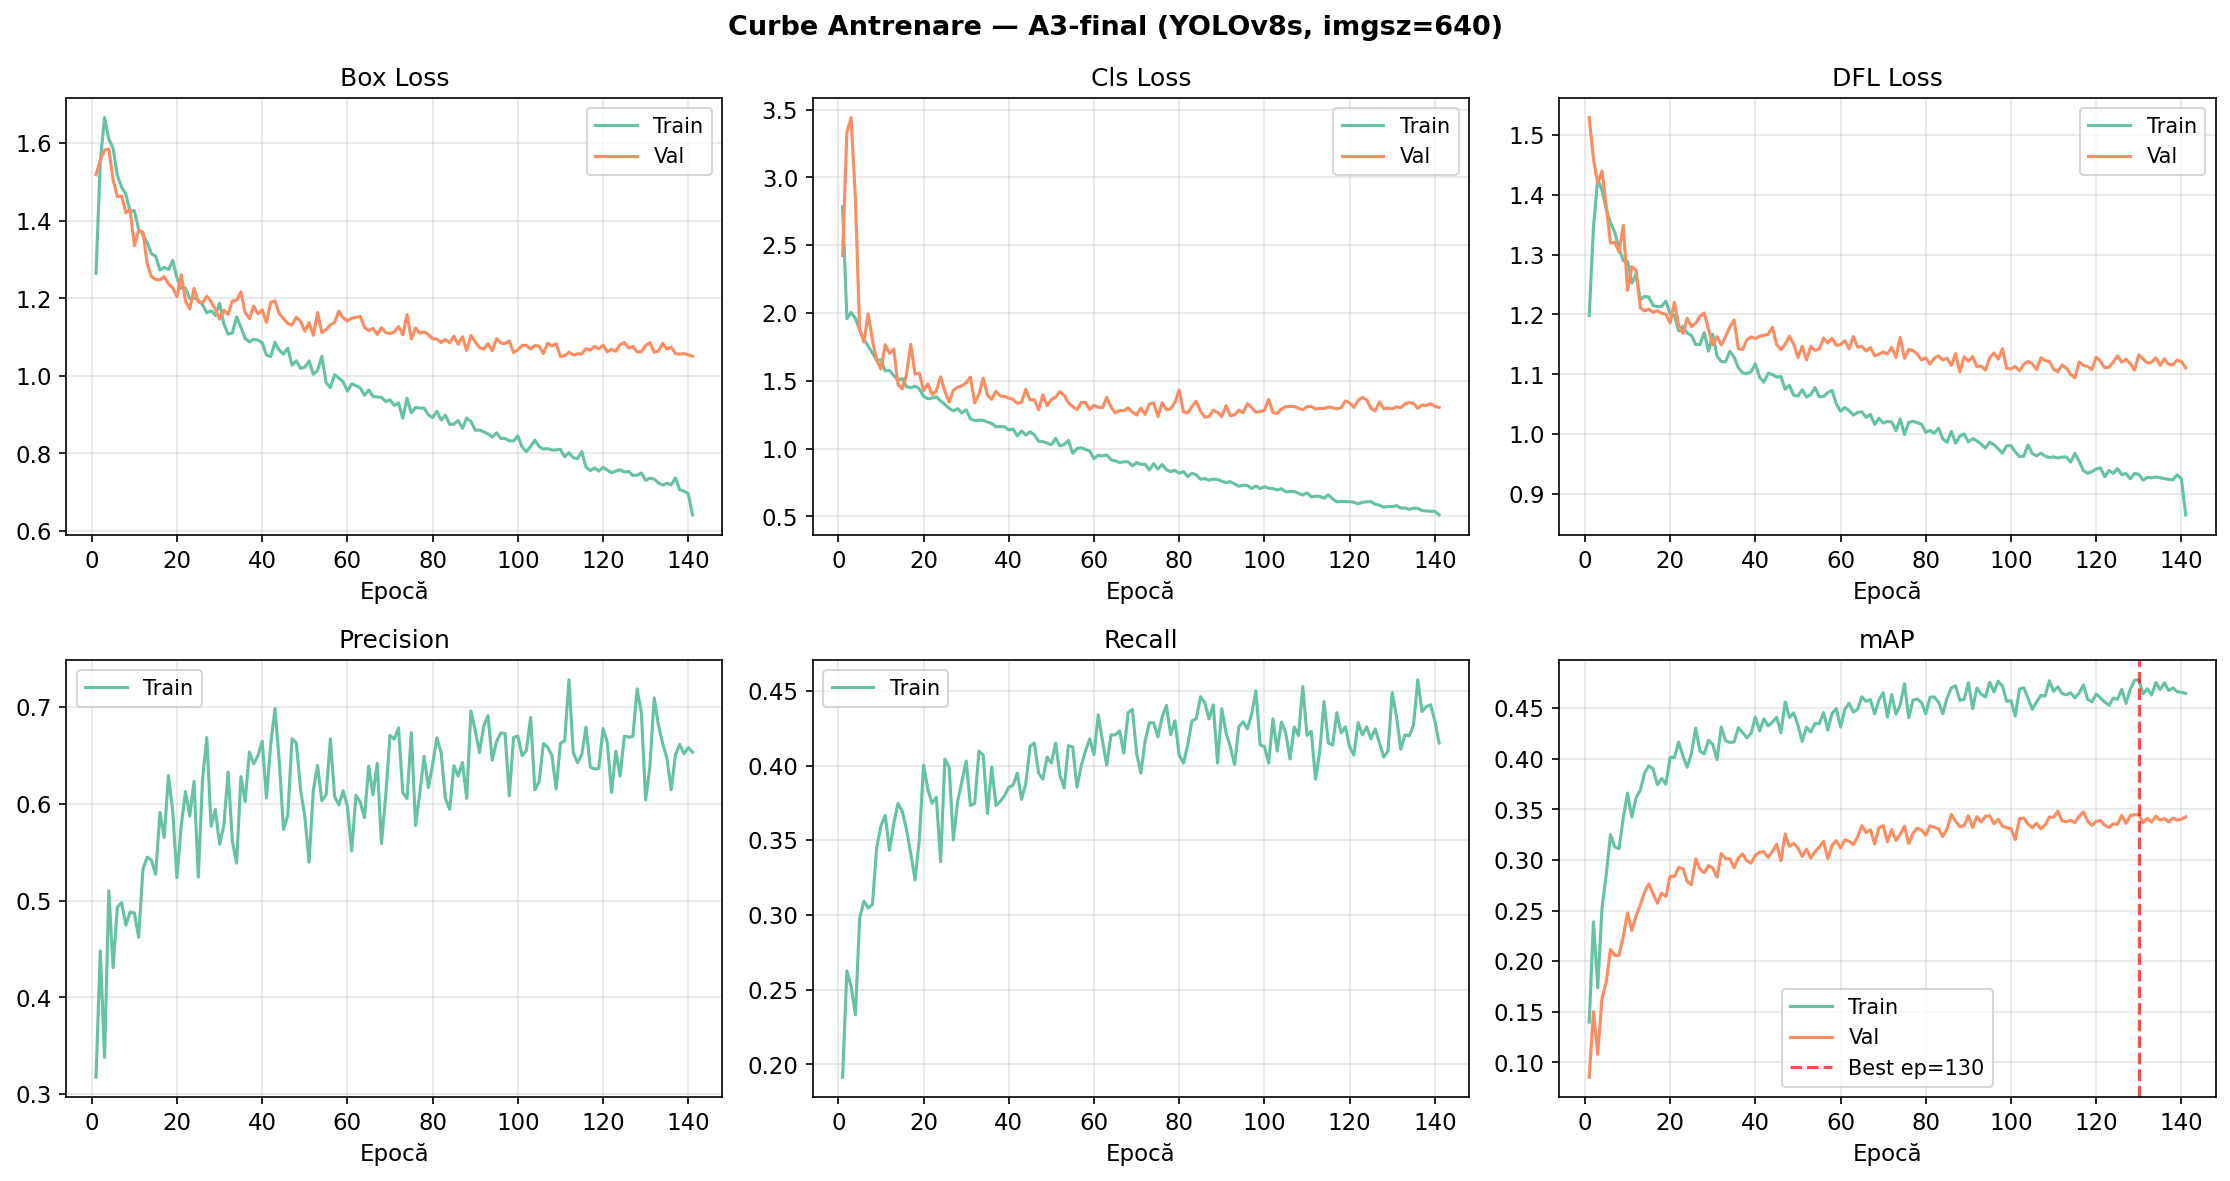

Saved: D:\TrashDetectionSystem\outputs\thesis_figures\F1_training_curves_A3final.png


In [5]:
# ── Load training CSV ─────────────────────────────────────────────────────────
csv_det = REPO_ROOT / 'runs/detect/parks-trash-A3-final/results.csv'
df_det = pd.read_csv(csv_det)
df_det.columns = df_det.columns.str.strip()
print('Columns:', list(df_det.columns))

epochs = df_det['epoch']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Curbe Antrenare — A3-final (YOLOv8s, imgsz=640)', fontsize=13, fontweight='bold')

plots = [
    ('train/box_loss',         'val/box_loss',         'Box Loss',      axes[0, 0]),
    ('train/cls_loss',         'val/cls_loss',         'Cls Loss',      axes[0, 1]),
    ('train/dfl_loss',         'val/dfl_loss',         'DFL Loss',      axes[0, 2]),
    ('metrics/precision(B)',   None,                   'Precision',     axes[1, 0]),
    ('metrics/recall(B)',      None,                   'Recall',        axes[1, 1]),
    ('metrics/mAP50(B)',       'metrics/mAP50-95(B)',  'mAP',           axes[1, 2]),
]

for train_col, val_col, title, ax in plots:
    if train_col in df_det.columns:
        ax.plot(epochs, df_det[train_col], label='Train', color=COLORS[0], linewidth=1.5)
    if val_col and val_col in df_det.columns:
        ax.plot(epochs, df_det[val_col], label='Val', color=COLORS[1], linewidth=1.5)
    elif train_col in df_det.columns and val_col is None:
        pass  # single line already plotted
    ax.set_title(title)
    ax.set_xlabel('Epocă')
    ax.legend()

# Highlight best epoch (mAP50)
if 'metrics/mAP50(B)' in df_det.columns:
    best_ep = df_det['metrics/mAP50(B)'].idxmax()
    axes[1, 2].axvline(epochs[best_ep], color='red', linestyle='--', alpha=0.7,
                       label=f'Best ep={epochs[best_ep]}')
    axes[1, 2].legend()

plt.tight_layout()
out = OUT_DIR / 'F1_training_curves_A3final.png'
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

---
## F2 — Curbe de Antrenare: Clasificator B2 (YOLOv8n-cls)

Columns: ['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


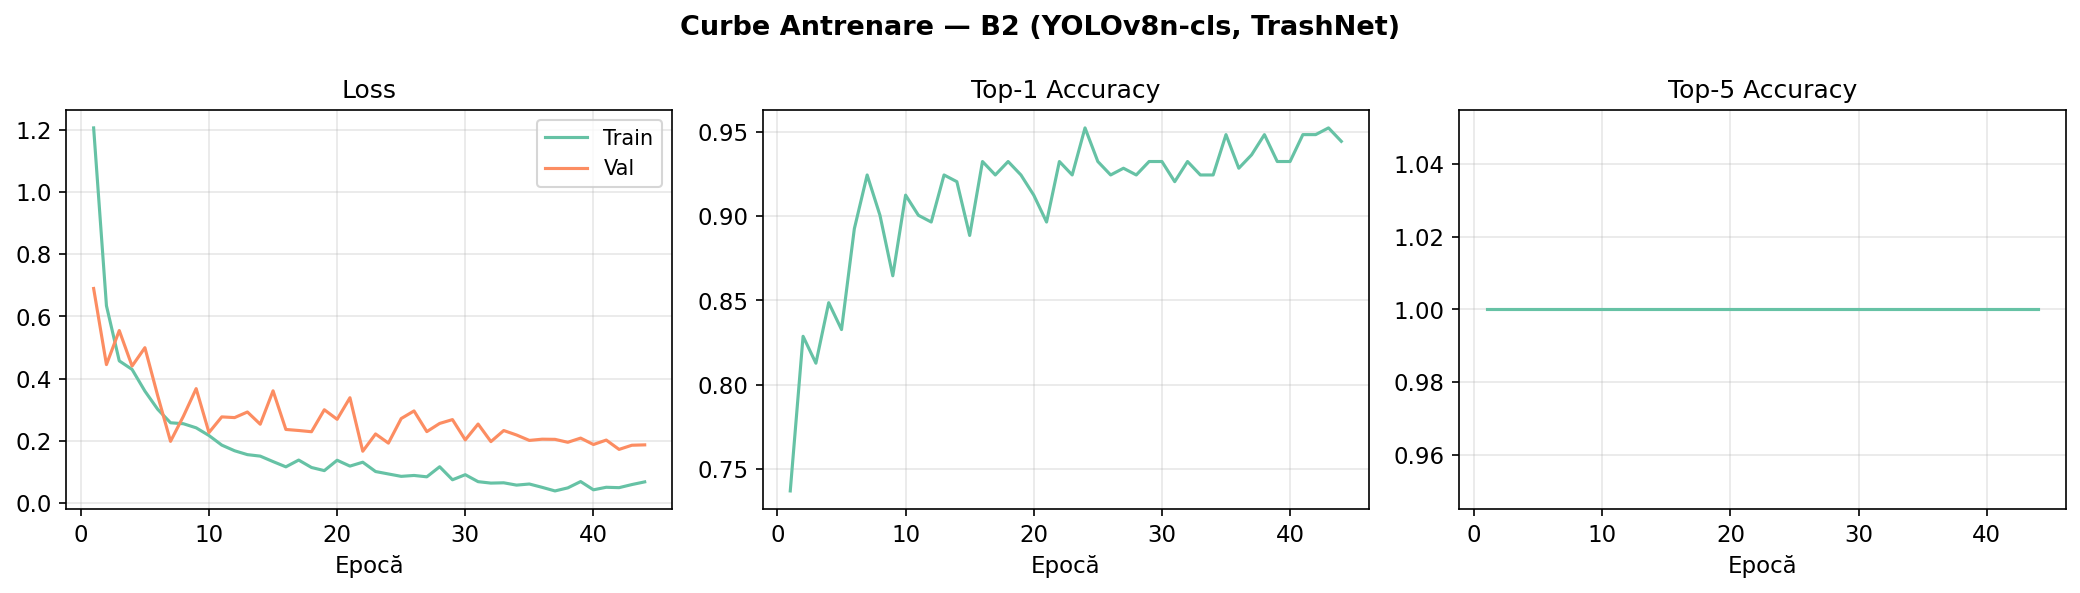

Saved: D:\TrashDetectionSystem\outputs\thesis_figures\F2_training_curves_B2.png


In [6]:
# ── Load classifier training CSV ──────────────────────────────────────────────
csv_cls = REPO_ROOT / 'runs/classify/parks-cls-B2/results.csv'
df_cls = pd.read_csv(csv_cls)
df_cls.columns = df_cls.columns.str.strip()
print('Columns:', list(df_cls.columns))

epochs_c = df_cls['epoch']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Curbe Antrenare — B2 (YOLOv8n-cls, TrashNet)', fontsize=13, fontweight='bold')

# Standard YOLO-cls columns: train/loss, val/loss, metrics/accuracy_top1
cls_plots = [
    ('train/loss', 'val/loss',                'Loss',           axes[0]),
    ('metrics/accuracy_top1', None,           'Top-1 Accuracy', axes[1]),
    ('metrics/accuracy_top5', None,           'Top-5 Accuracy', axes[2]),
]

for train_col, val_col, title, ax in cls_plots:
    if train_col in df_cls.columns:
        ax.plot(epochs_c, df_cls[train_col], label='Train' if val_col else title,
                color=COLORS[0], linewidth=1.5)
    if val_col and val_col in df_cls.columns:
        ax.plot(epochs_c, df_cls[val_col], label='Val', color=COLORS[1], linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel('Epocă')
    if val_col:
        ax.legend()

plt.tight_layout()
out = OUT_DIR / 'F2_training_curves_B2.png'
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

---
## F3 — Matrice de Confuzie: Clasificator B2

Copied: D:\TrashDetectionSystem\outputs\thesis_figures\F3_confusion_matrix_B2.png


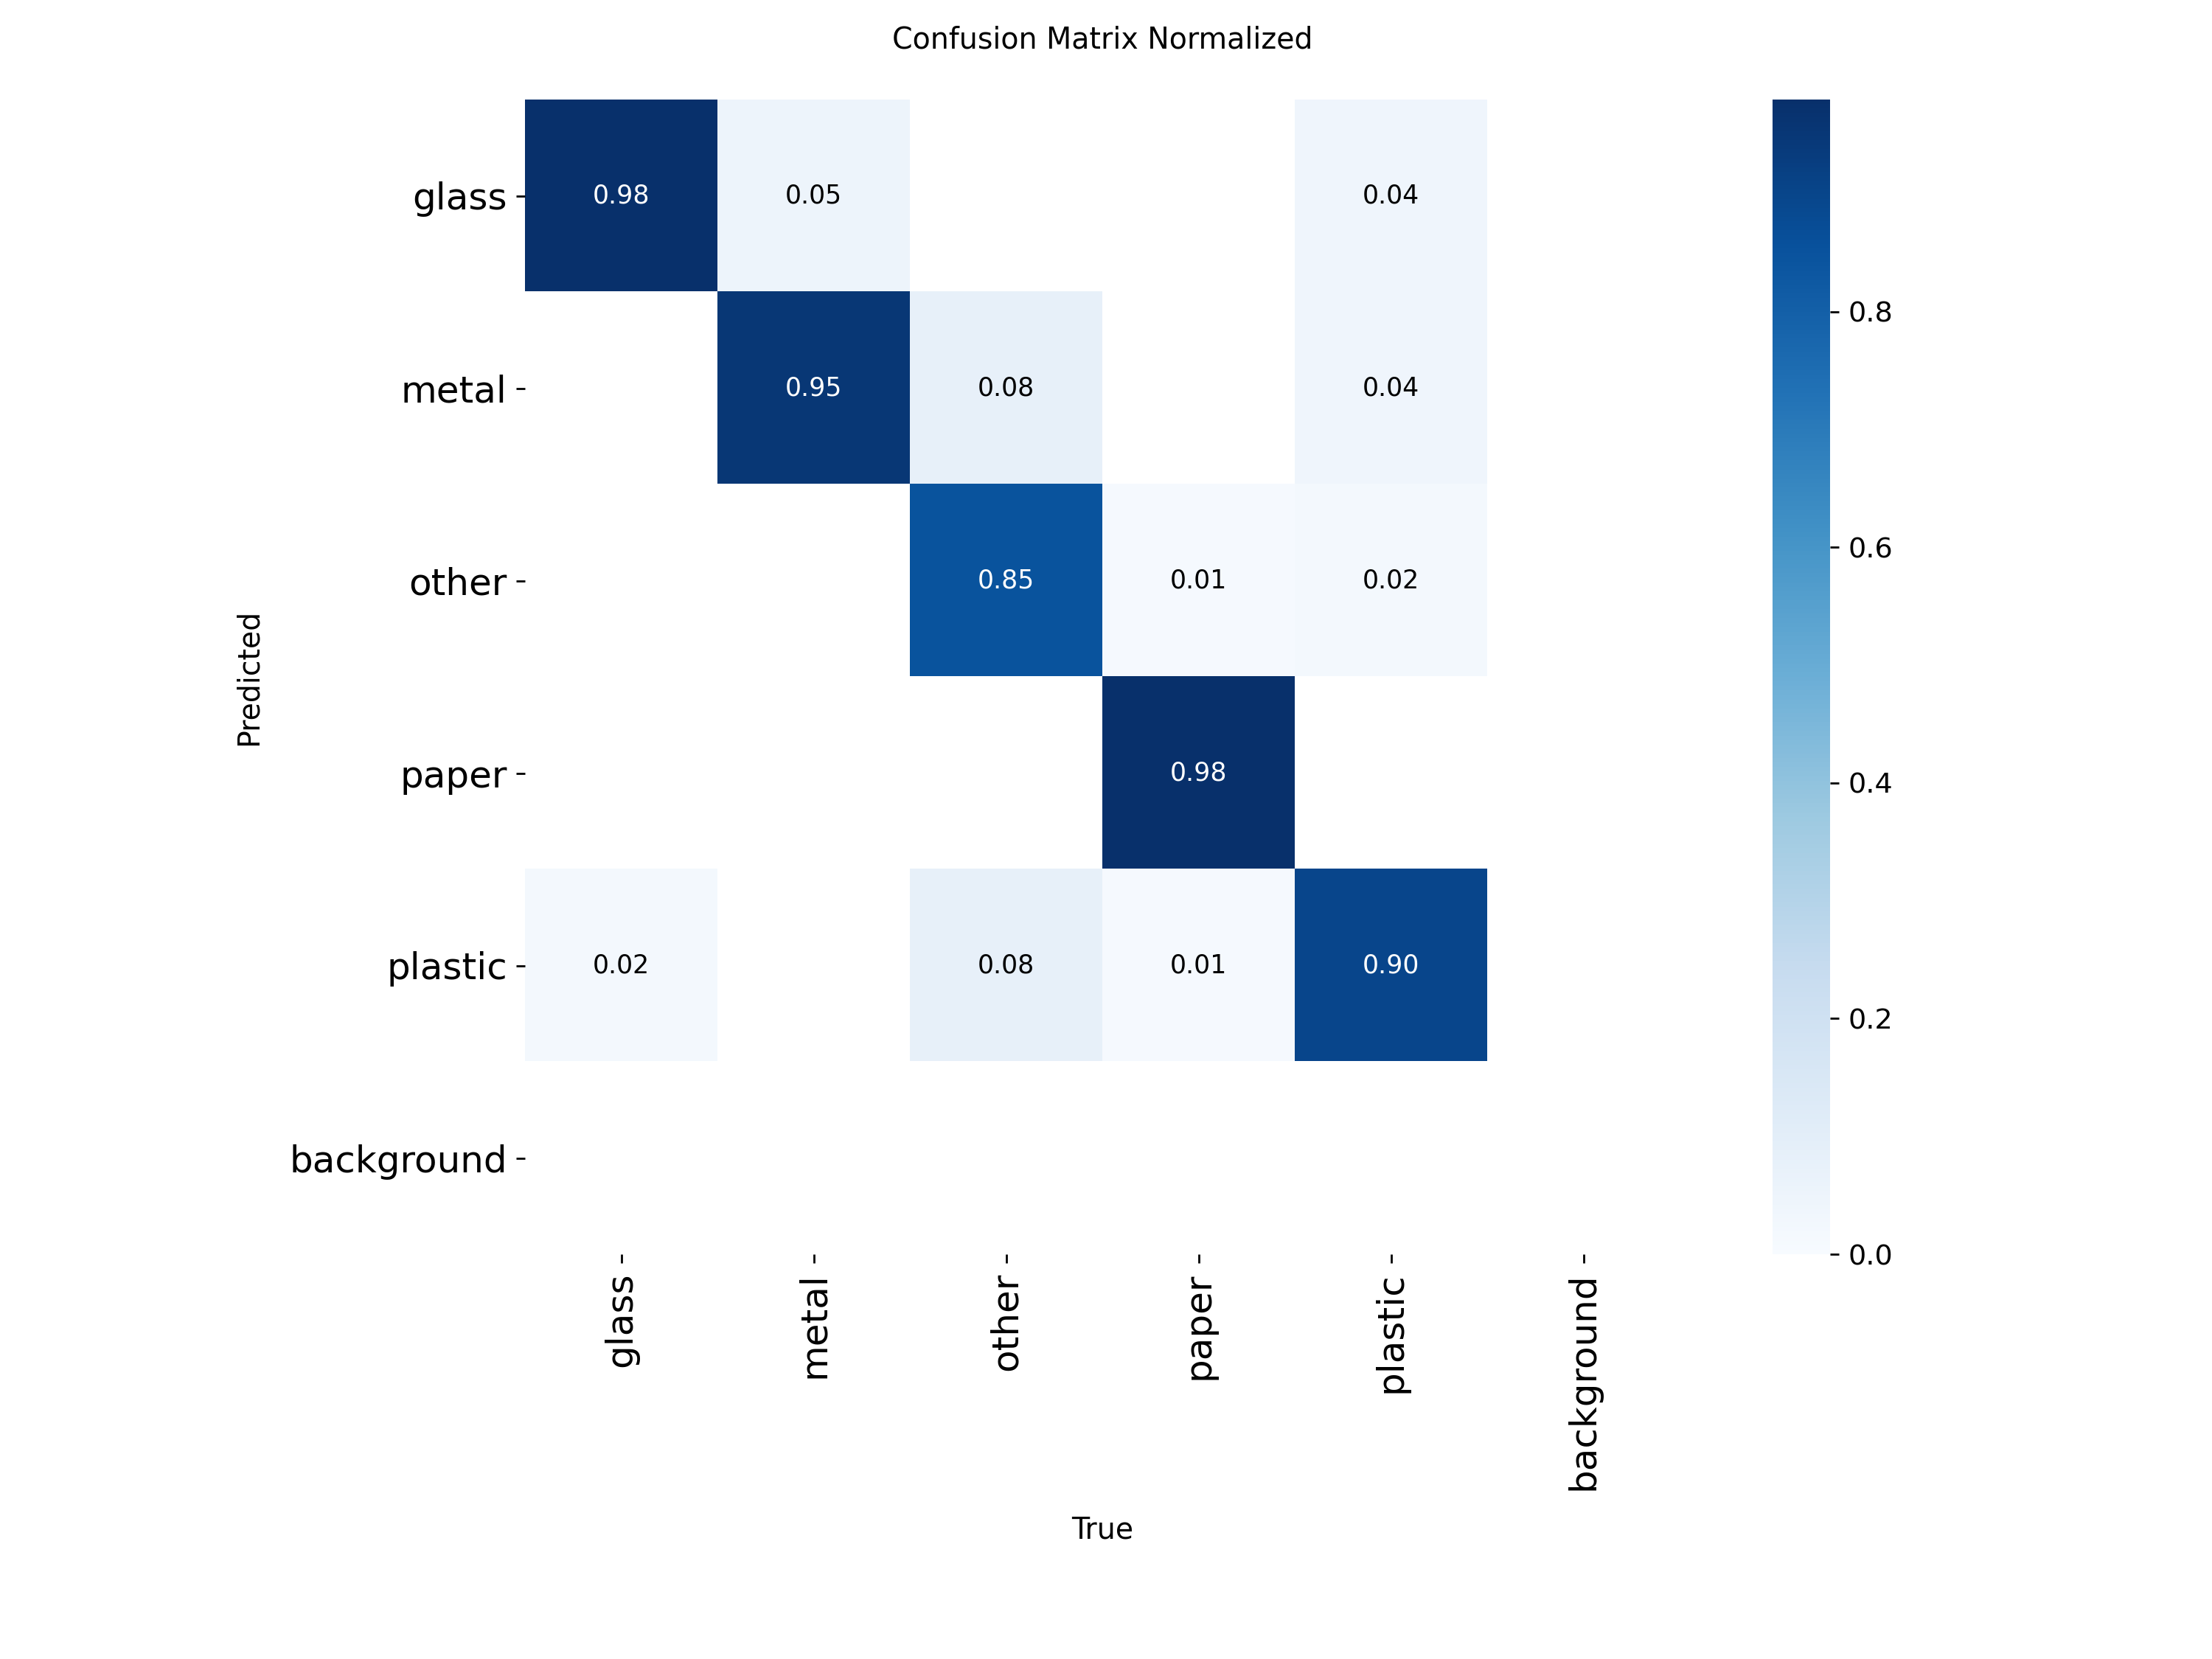

In [7]:
from IPython.display import Image as IPImage, display

# Copy confusion matrix from training run
src_cm = REPO_ROOT / 'runs/classify/parks-cls-B2/confusion_matrix_normalized.png'
dst_cm = OUT_DIR / 'F3_confusion_matrix_B2.png'
shutil.copy2(src_cm, dst_cm)
print(f'Copied: {dst_cm}')
display(IPImage(filename=str(dst_cm), width=600))

---
## F4 — Scoruri F1 per-clasă: B2 vs B3

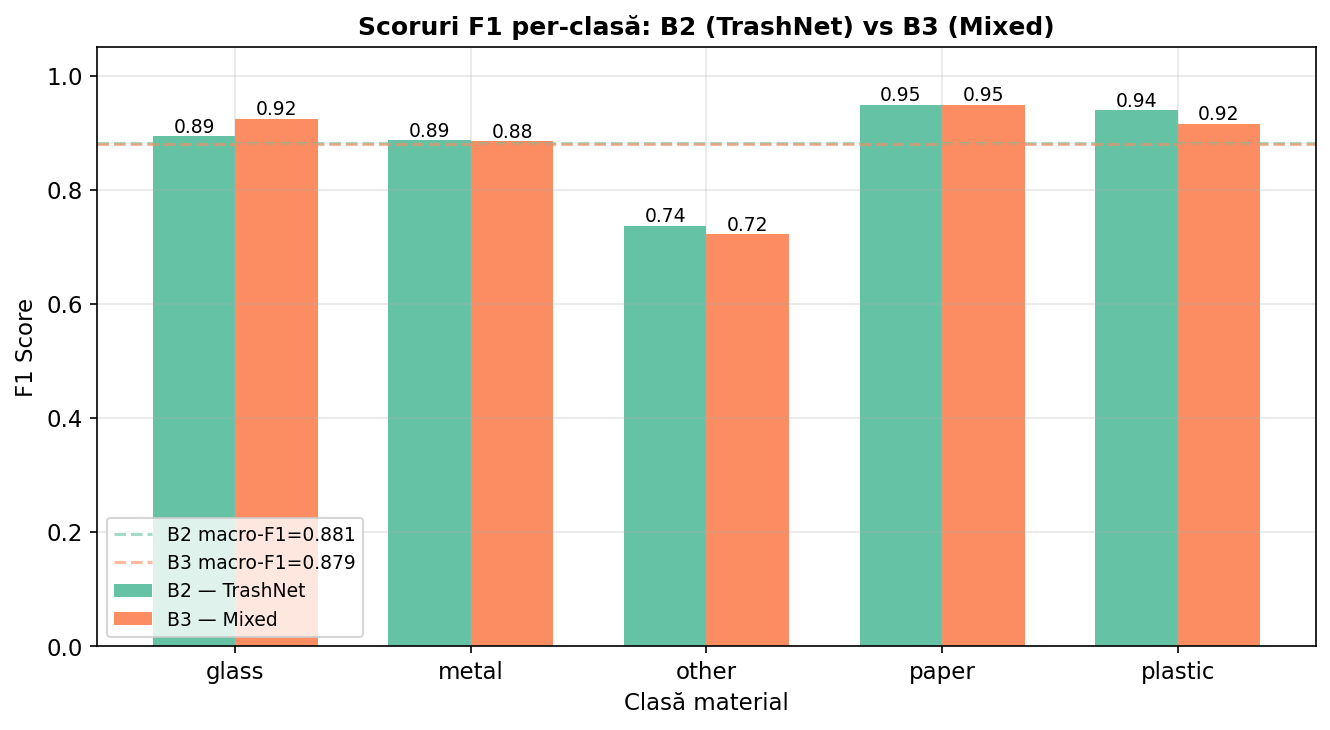

Saved: D:\TrashDetectionSystem\outputs\thesis_figures\F4_f1_per_class_B2_vs_B3.png


In [8]:
# ── Per-class F1 grouped bar chart ────────────────────────────────────────────
classes   = CLASSES
f1_b2 = [b2['per_class'][c]['f1'] for c in classes]
f1_b3 = [b3['per_class'][c]['f1'] for c in classes]

x     = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, f1_b2, width, label='B2 — TrashNet', color=COLORS[0])
bars2 = ax.bar(x + width/2, f1_b3, width, label='B3 — Mixed',    color=COLORS[1])

ax.set_title('Scoruri F1 per-clasă: B2 (TrashNet) vs B3 (Mixed)', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_xlabel('Clasă material')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.05)
ax.legend()
ax.bar_label(bars1, fmt='%.2f', fontsize=9)
ax.bar_label(bars2, fmt='%.2f', fontsize=9)

# Add macro-F1 lines
ax.axhline(b2['macro_f1'], color=COLORS[0], linestyle='--', alpha=0.6,
           label=f'B2 macro-F1={b2["macro_f1"]:.3f}')
ax.axhline(b3['macro_f1'], color=COLORS[1], linestyle='--', alpha=0.6,
           label=f'B3 macro-F1={b3["macro_f1"]:.3f}')
ax.legend(fontsize=9)

plt.tight_layout()
out = OUT_DIR / 'F4_f1_per_class_B2_vs_B3.png'
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

---
## F5 — Distribuție clase dataset TrashNet (B2 training data)

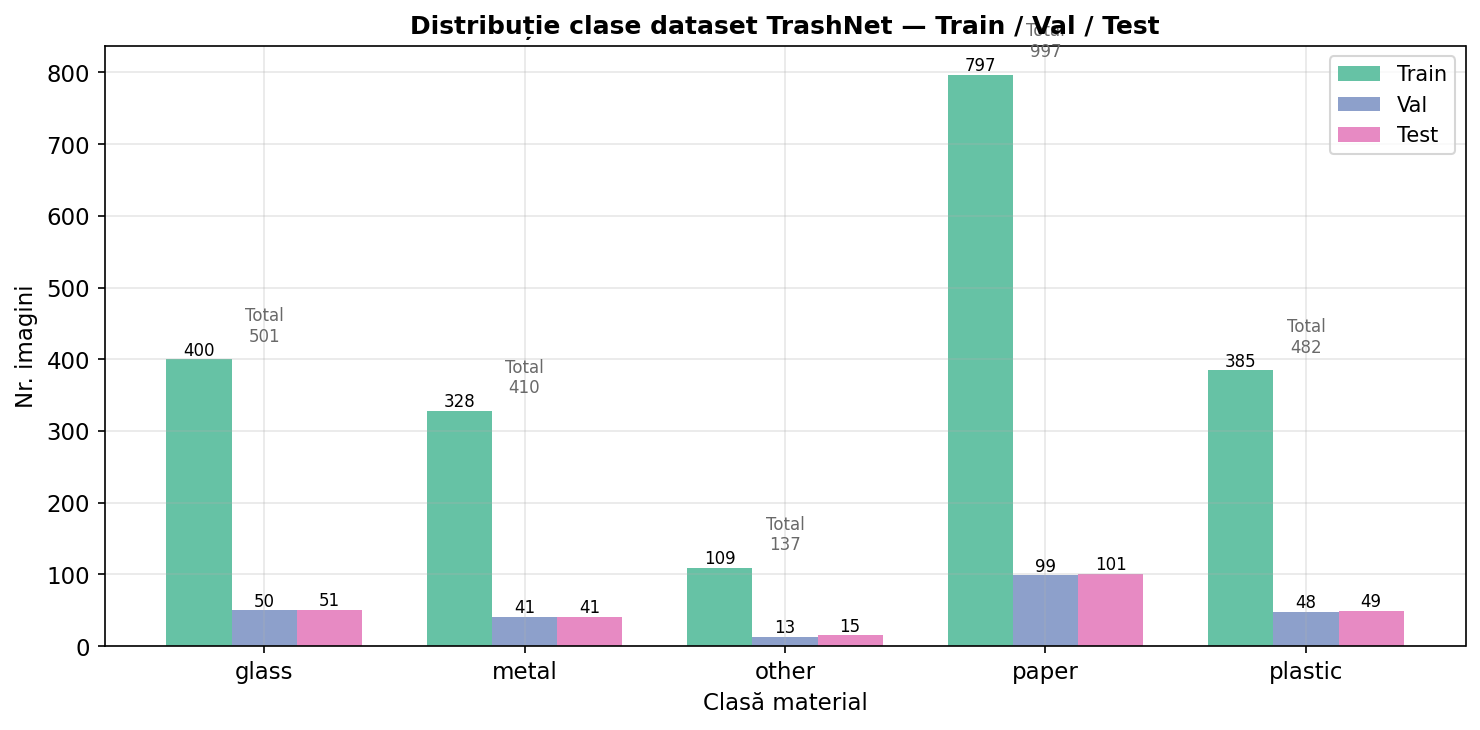

Saved: D:\TrashDetectionSystem\outputs\thesis_figures\F5_dataset_distribution_trashnet.png


In [9]:
# ── Count images per class per split ─────────────────────────────────────────
cls_root = REPO_ROOT / 'datasets/trashnet_cls'
splits   = ['train', 'val', 'test']

dist = {}
for split in splits:
    dist[split] = {}
    for cls in CLASSES:
        p = cls_root / split / cls
        dist[split][cls] = len(list(p.glob('*'))) if p.exists() else 0

# ── Stacked bar chart ─────────────────────────────────────────────────────────
x     = np.arange(len(CLASSES))
width = 0.25
offsets = [-width, 0, width]
split_colors = [COLORS[0], COLORS[2], COLORS[3]]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (split, offset, color) in enumerate(zip(splits, offsets, split_colors)):
    vals = [dist[split][c] for c in CLASSES]
    bars = ax.bar(x + offset, vals, width, label=split.capitalize(), color=color)
    ax.bar_label(bars, fontsize=8)

ax.set_title('Distribuție clase dataset TrashNet — Train / Val / Test', fontweight='bold')
ax.set_ylabel('Nr. imagini')
ax.set_xlabel('Clasă material')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.legend()

# Totals annotation
for i, cls in enumerate(CLASSES):
    total = sum(dist[s][cls] for s in splits)
    ax.text(i, max(dist[s][cls] for s in splits) + 25, f'Total\n{total}',
            ha='center', fontsize=8, color='dimgray')

plt.tight_layout()
out = OUT_DIR / 'F5_dataset_distribution_trashnet.png'
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

---
## F6 — Distribuție materiale detectate: Pipeline C2

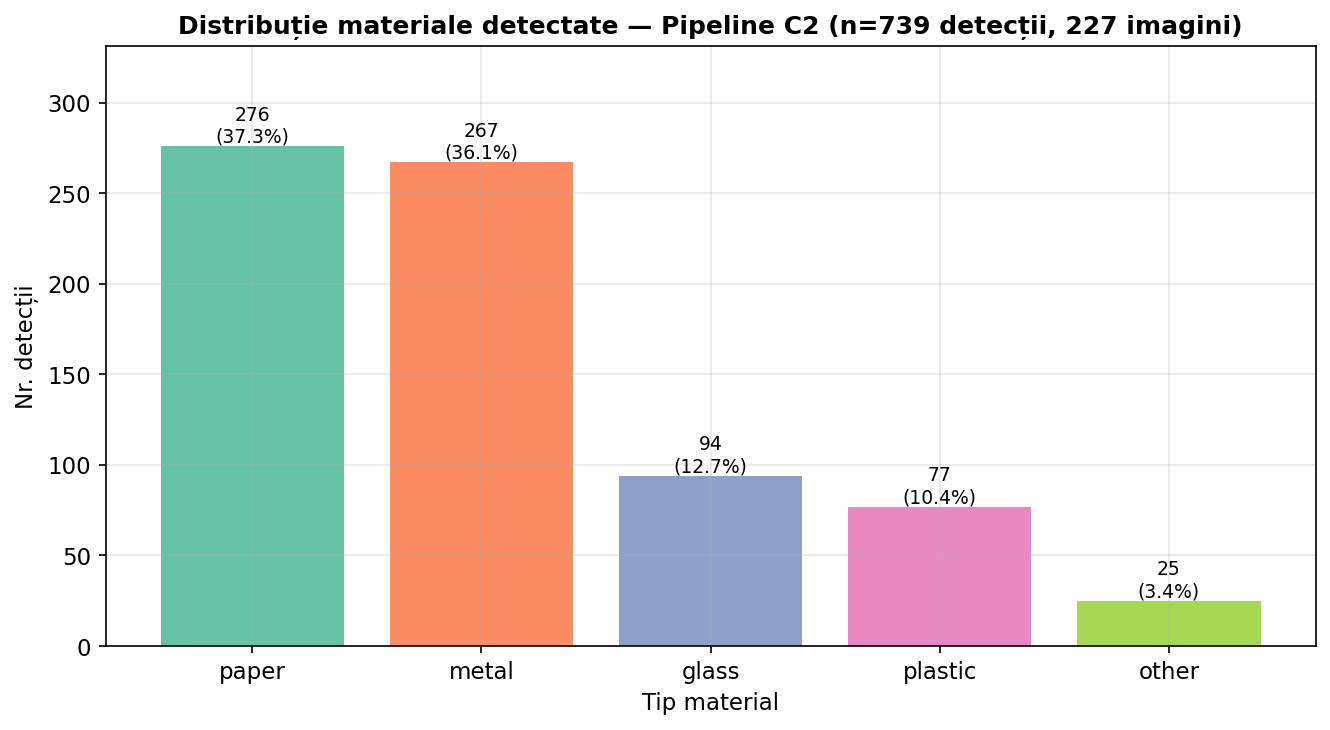

Saved: D:\TrashDetectionSystem\outputs\thesis_figures\F6_material_distribution_C2.png


In [10]:
# ── Material distribution from best pipeline (C2) ─────────────────────────────
mat_dist = c2['material_dist']
mat_sorted = dict(sorted(mat_dist.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(9, 5))
materials = list(mat_sorted.keys())
counts    = list(mat_sorted.values())
total_det = sum(counts)

bars = ax.bar(materials, counts, color=COLORS[:len(materials)])
ax.bar_label(bars, labels=[f'{v}\n({v/total_det*100:.1f}%)' for v in counts], fontsize=9)
ax.set_title(f'Distribuție materiale detectate — Pipeline C2 (n={total_det} detecții, 227 imagini)',
             fontweight='bold')
ax.set_ylabel('Nr. detecții')
ax.set_xlabel('Tip material')
ax.set_ylim(0, max(counts) * 1.2)

plt.tight_layout()
out = OUT_DIR / 'F6_material_distribution_C2.png'
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

---
## F7 — Detector: mAP comparație vizuală A22 vs A3-final

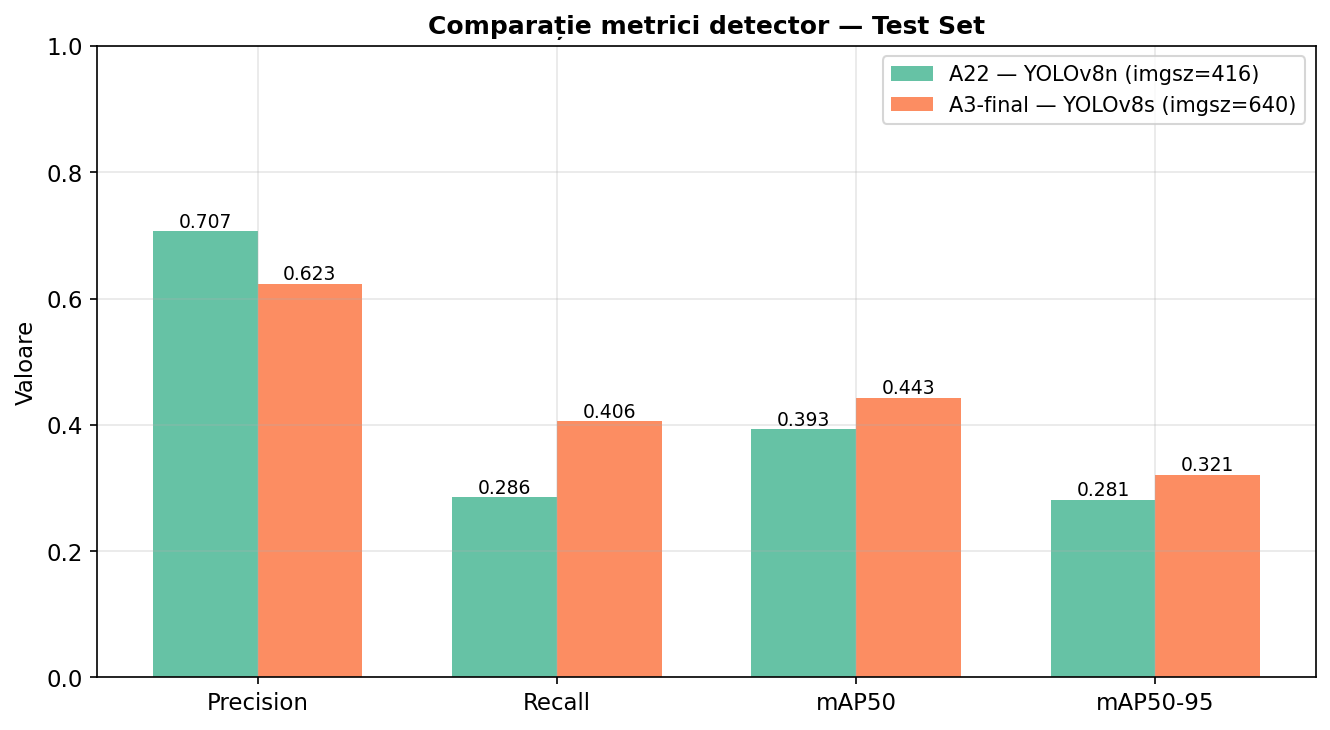

Saved: D:\TrashDetectionSystem\outputs\thesis_figures\F7_detector_metrics_A22_vs_A3final.png


In [11]:
# ── Side-by-side metric comparison bars ───────────────────────────────────────
metrics_det = ['Precision', 'Recall', 'mAP50', 'mAP50-95']
vals_a22 = [
    a22['precision'], a22['recall'],
    a22['map50'],     a22['map50_95'],
]
vals_a3 = [
    a3['precision'], a3['recall'],
    a3['mAP50'],     a3['mAP50_95'],
]

x     = np.arange(len(metrics_det))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, vals_a22, width, label='A22 — YOLOv8n (imgsz=416)', color=COLORS[0])
b2_ = ax.bar(x + width/2, vals_a3,  width, label='A3-final — YOLOv8s (imgsz=640)', color=COLORS[1])

ax.set_title('Comparație metrici detector — Test Set', fontweight='bold')
ax.set_ylabel('Valoare')
ax.set_xticks(x)
ax.set_xticklabels(metrics_det)
ax.set_ylim(0, 1.0)
ax.legend()
ax.bar_label(b1,  fmt='%.3f', fontsize=9)
ax.bar_label(b2_, fmt='%.3f', fontsize=9)

plt.tight_layout()
out = OUT_DIR / 'F7_detector_metrics_A22_vs_A3final.png'
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

---
## Sumar — Toate fișierele generate

In [12]:
print(f'Figuri salvate în: {OUT_DIR}\n')
for f in sorted(OUT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<50}  {size_kb:6.1f} KB')

Figuri salvate în: D:\TrashDetectionSystem\outputs\thesis_figures

  F1_training_curves_A3final.png                       269.7 KB
  F2_training_curves_B2.png                             87.9 KB
  F3_confusion_matrix_B2.png                           143.0 KB
  F4_f1_per_class_B2_vs_B3.png                          52.9 KB
  F5_dataset_distribution_trashnet.png                  52.9 KB
  F6_material_distribution_C2.png                       46.3 KB
  F7_detector_metrics_A22_vs_A3final.png                44.6 KB
